In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

In [2]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = Image.open(filename)
img_array = np.array(img)

Saving VIER PFOTEN_2017-10-20_164-3672x2448-3672x2448-1920x1280.jpg to VIER PFOTEN_2017-10-20_164-3672x2448-3672x2448-1920x1280.jpg


In [ ]:
#EXERCISE 1

In [ ]:
""" Q1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image. """

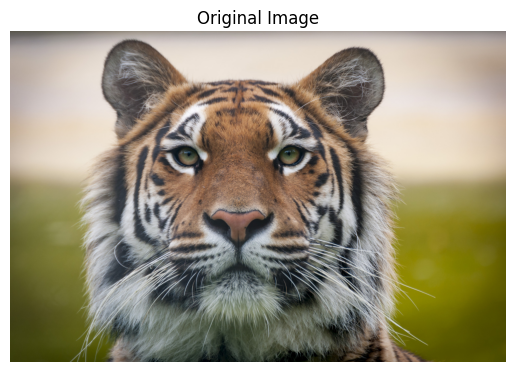

In [3]:
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
""" Q2. Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing."""

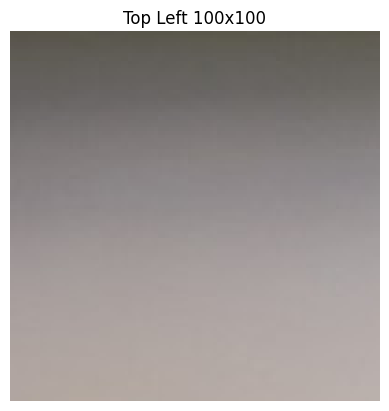

In [4]:
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.axis("off")
plt.show()

In [ ]:
""" Q3. Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.} """

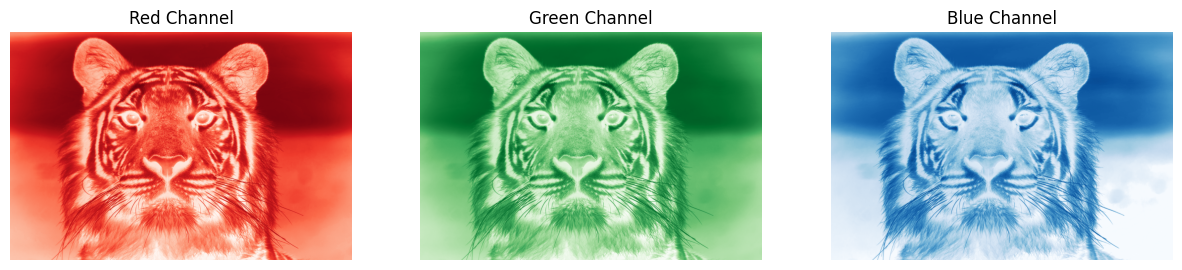

In [5]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

In [ ]:
"""Q4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image. """

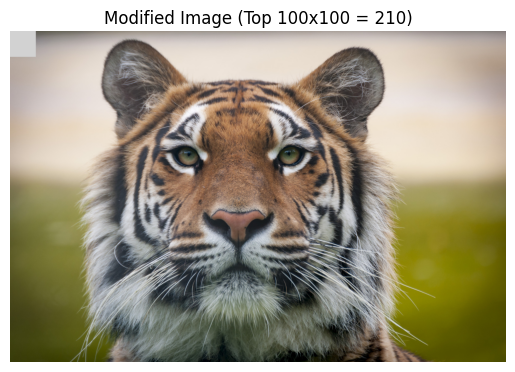

In [6]:
modified = img_array.copy()
modified[0:100, 0:100] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

In [ ]:
#EXERCISE 2

In [ ]:
""" Q1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib."""

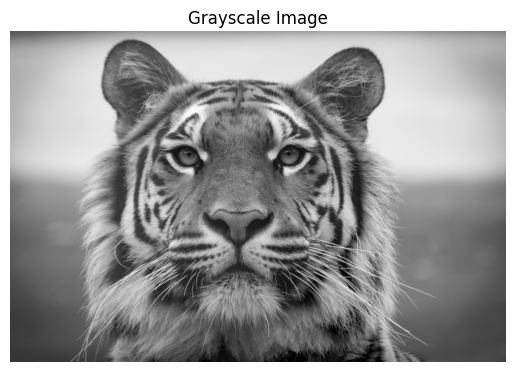

In [7]:
gray_img = img.convert("L")
gray_array = np.array(gray_img)

plt.imshow(gray_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [ ]:
""" Q2. Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib. """

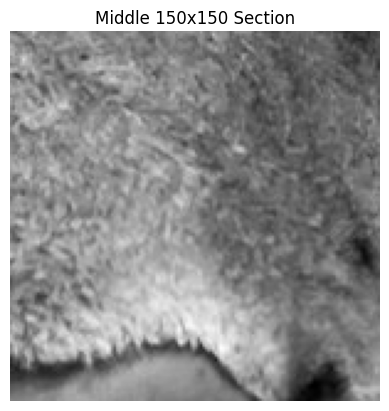

In [8]:
h, w = gray_array.shape

middle = gray_array[h//2-75:h//2+75,
                    w//2-75:w//2+75]

plt.imshow(middle, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

In [ ]:
""" Q3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image. """

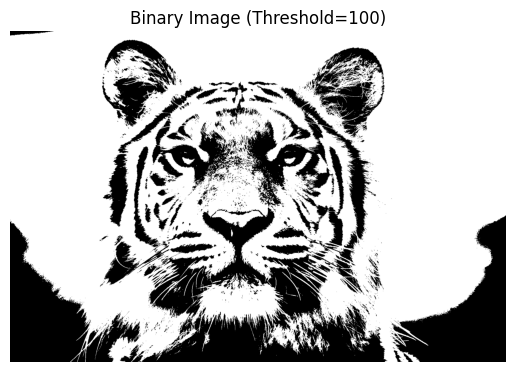

In [9]:
binary = gray_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap='gray')
plt.title("Binary Image (Threshold=100)")
plt.axis("off")
plt.show()

In [ ]:
""" Q4. Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib. """

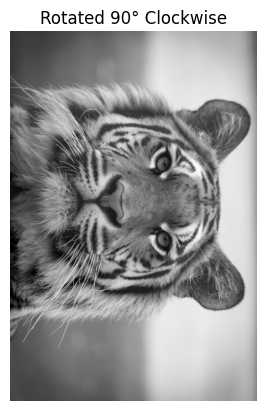

In [10]:
rotated = gray_img.rotate(-90, expand=True)

plt.imshow(rotated, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis("off")
plt.show()

In [ ]:
""" Q5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib. """

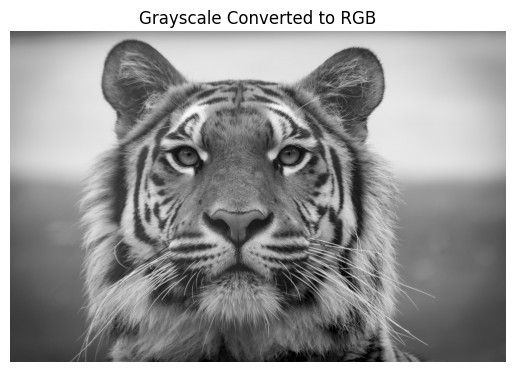

In [11]:
rgb_from_gray = gray_img.convert("RGB")

plt.imshow(rgb_from_gray)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

In [ ]:
#EXERCISE 3 – PCA FROM SCRATCH

In [ ]:
""" Q1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset - Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data. """

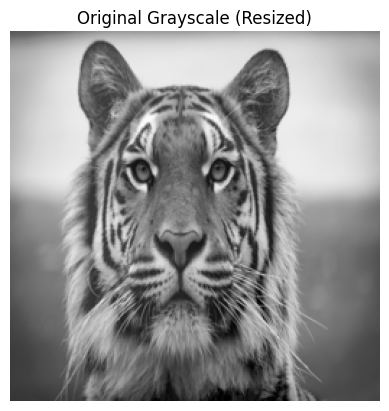

In [12]:
gray_img = gray_img.resize((256,256))
X = np.array(gray_img, dtype=float)

plt.imshow(X, cmap='gray')
plt.title("Original Grayscale (Resized)")
plt.axis("off")
plt.show()

mean = np.mean(X, axis=0)
X_centered = X - mean

In [13]:
cov_matrix = np.cov(X_centered, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (256, 256)


In [ ]:
""" Q2. Eigen Decomposition and Identifying Principal Components:
• Compute Eigen Values and Eigen Vectors.
• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
• Identify the Principal Components with the help of cumulative Sum plot. """

In [15]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

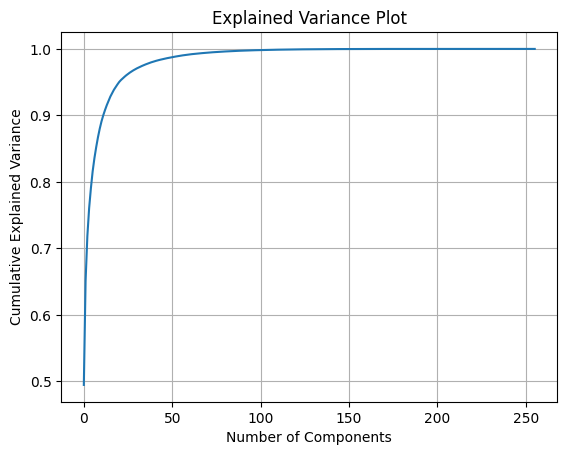

In [16]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

In [ ]:
""" Q3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate. """

In [17]:
def reconstruct(k):
    PCs = eigenvectors[:, :k]
    projected = np.dot(X_centered, PCs)
    reconstructed = np.dot(projected, PCs.T) + mean
    return reconstructed

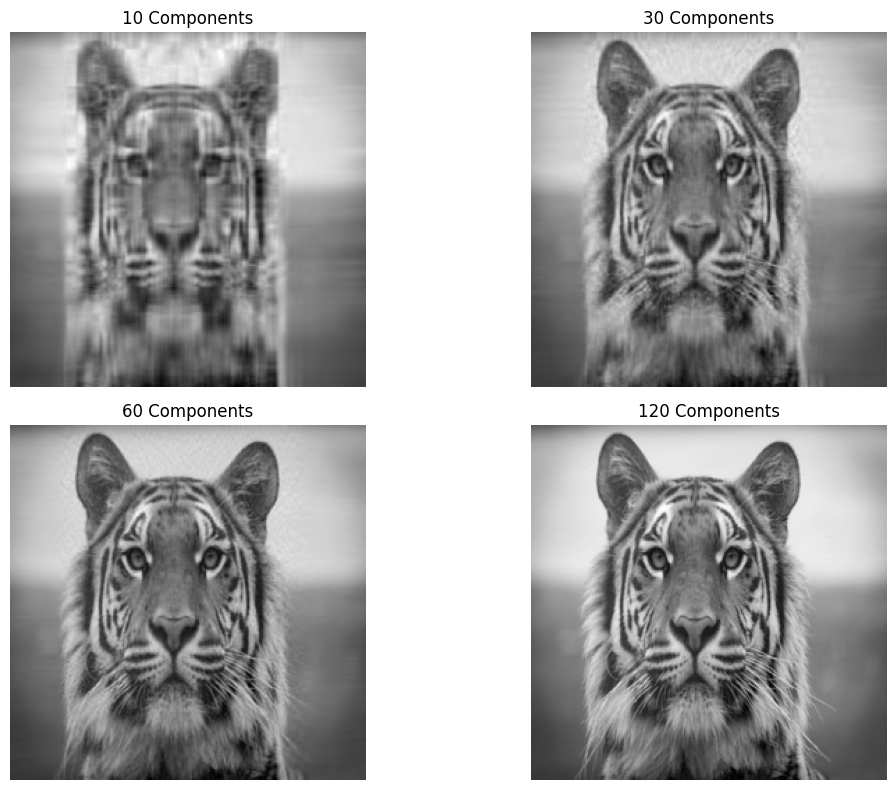

In [18]:
k_values = [10, 30, 60, 120]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):
    recon = reconstruct(k)

    plt.subplot(2,2,i+1)
    plt.imshow(recon, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Final Comparison (Original vs Best)

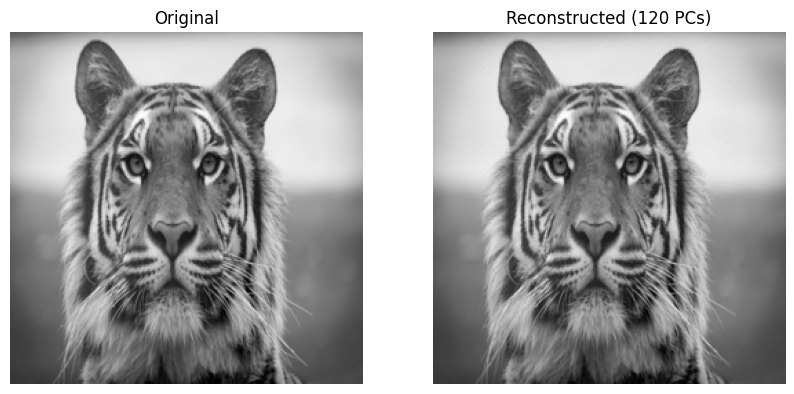

In [19]:
best_k = 120
best = reconstruct(best_k)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best, cmap='gray')
plt.title(f"Reconstructed ({best_k} PCs)")
plt.axis("off")

plt.show()